# redmapper inputs checks
currently these files exist in my RSP path under ``~/dp2_redmapper``. Not sure if you're able to access that.

In [1]:
import os, sys, glob
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import healsparse as hsp
import fitsio
import skyproj

import redmapper_dp2_common as common

bands = 'riz'
vis_min = 3
nside = 4096
nside_sparse = 131072
test_tracts = [10188, 8228]

base_dir = os.path.expanduser('~/dp2_redmapper')
map_dir = os.path.join(base_dir, 'maps')
old_map_dir = os.path.join(base_dir, 'maps_objectbased')   ## the superseded object-based maps
cat_dir = os.path.join(base_dir, 'catalogs')
specz_dir = os.path.join(base_dir, 'specz')

## Load everything

In [7]:
## maps
geometry = hsp.HealSparseMap.read(common.mask_file(map_dir, bands, vis_min, nside))
depth = {d: hsp.HealSparseMap.read(common.depth_file(map_dir, bands, vis_min, nside, d))
         for d in ['min', 'r', 'i', 'z']}

geom_pix = geometry.valid_pixels
geom_ra, geom_dec = common.pixel_centers(nside, geom_pix)
fracgood = geometry.get_values_pix(geom_pix)
limmag = {d: depth[d].get_values_pix(geom_pix)['limmag'] for d in depth}

pa = common.pix_area(nside)
print(f'geometry: {len(geom_pix)} pixels, {len(geom_pix) * pa:.1f} deg^2 touched, '
      f'{np.sum(fracgood) * pa:.1f} deg^2 fracgood weighted')

## spec-z
specz = fitsio.read(os.path.join(specz_dir, f'dp2_specz_desi_dr1_{bands}_vis{vis_min}.fit'), lower=True)
print(f'spec-z: {len(specz)}')

geometry: 6127224 pixels, 1255.5 deg^2 touched, 1047.7 deg^2 fracgood weighted
spec-z: 527159


In [8]:
## per-tract flux files, and the built catalog if it's there yet
flux_files = sorted(glob.glob(common.flux_file(cat_dir, '*', bands, vis_min)))
empty_files = glob.glob(common.flux_file(cat_dir, '*', bands, vis_min) + '.empty')
print(f'{len(flux_files)} tract flux files ({len(empty_files)} empty)')

cat_base = common.catalog_base(cat_dir, 'cmodel', 'sersic', bands, vis_min)
master_file = cat_base + '_master_table.fit'
have_catalog = os.path.exists(master_file)
print(f'built catalog: {master_file if have_catalog else "not built yet"}')

886 tract flux files (1288 empty)
built catalog: /home/dericj/dp2_redmapper/catalogs/dp2_photo_refcmodel_colsersic_riz_vis3_master_table.fit


## Geometry mask

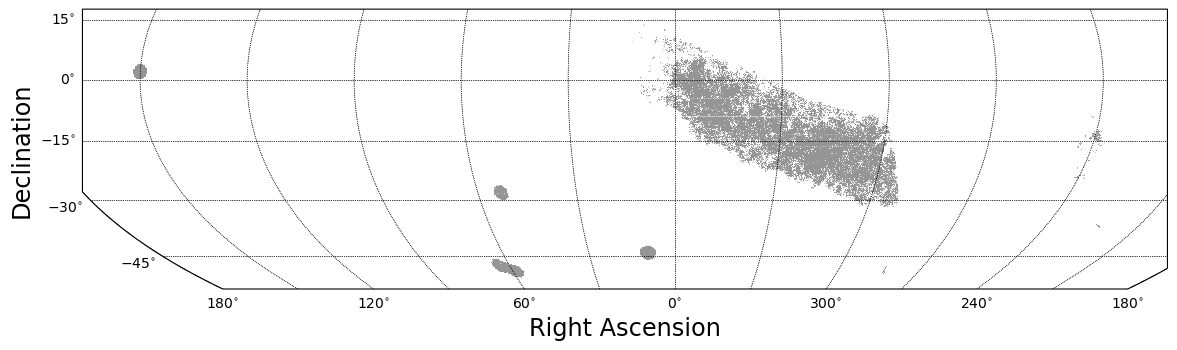

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))
sp = skyproj.McBrydeSkyproj(ax=ax, lon_0=0.0)
sp.draw_hspmap(geometry, cmap='Greys', vmin=0, vmax=2)
ax.set_title(f'geometry mask ({bands}, vis_min {vis_min}, 2x2 block), '
             f'{np.sum(fracgood) * pa:.1f} deg$^2$')
plt.show()

### How much swiss cheese?

`fracgood` is the fraction of each nside 4096 pixel that is actually inside a good cell, so
anything below 1 is holes. On the two test tracts alone the median was 0.82, but over the full
footprint neighbouring tracts fill each other's gaps, so most pixels come out solid.

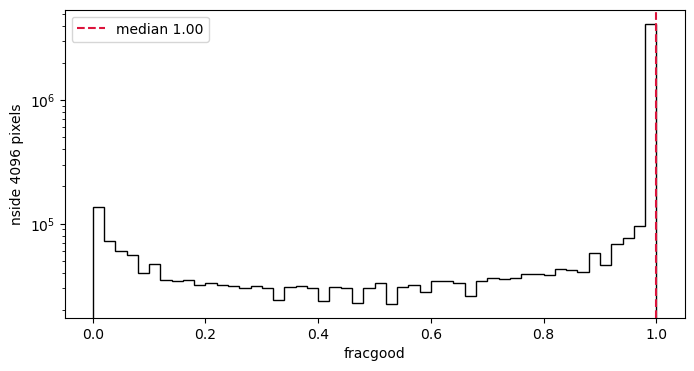

fracgood >= 1.0: 64.5% of pixels
fracgood >= 0.9: 72.2% of pixels
fracgood >= 0.5: 83.9% of pixels


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(fracgood, bins=np.linspace(0, 1, 51), histtype='step', color='k')
ax.axvline(np.median(fracgood), color='crimson', ls='--',
           label=f'median {np.median(fracgood):.2f}')
ax.set_xlabel('fracgood')
ax.set_ylabel('nside 4096 pixels')
ax.set_yscale('log')
ax.legend()
plt.show()

for cut in [1.0, 0.9, 0.5]:
    frac = np.mean(fracgood >= cut)
    print(f'fracgood >= {cut}: {100 * frac:.1f}% of pixels')

Zoom in on one test tract at cell resolution, where the holes are actually visible.

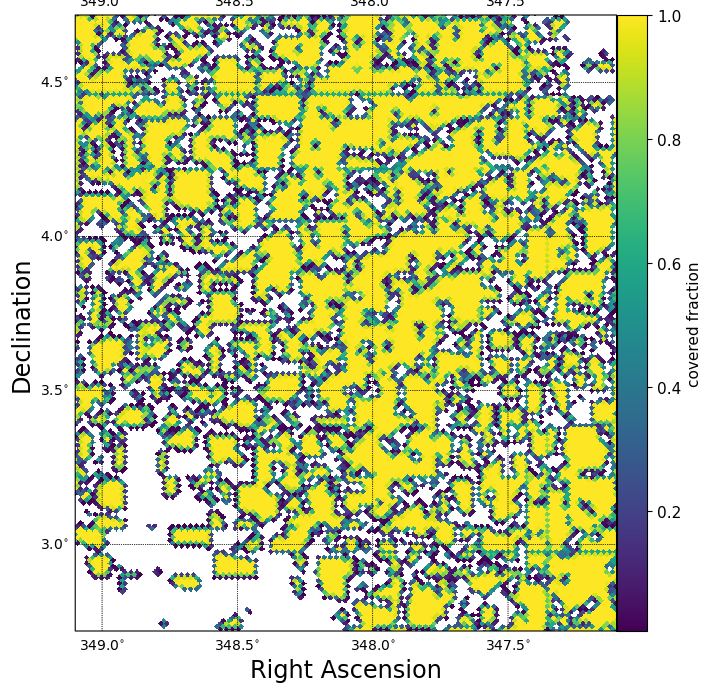

In [11]:
## the bitpacked map is the cell-resolution truth the catalog filters on
fine = hsp.HealSparseMap.read(common.bitpacked_file(map_dir, bands, vis_min, nside_sparse))

butler, skymap = common.open_butler()
tract_info = skymap[test_tracts[0]]
center = tract_info.ctr_coord
ra0, dec0 = center.getRa().asDegrees(), center.getDec().asDegrees()

fig, ax = plt.subplots(figsize=(9, 8))
sp = skyproj.McBrydeSkyproj(ax=ax, lon_0=ra0)
sp.draw_hspmap(fine.fracdet_map(4096), cmap='viridis', vmin=0, vmax=1)
sp.set_extent([ra0 - 1.0, ra0 + 1.0, dec0 - 1.0, dec0 + 1.0])
sp.draw_colorbar(label='covered fraction')
ax.set_title(f'tract {test_tracts[0]}, cell-resolution geometry')
plt.show()

## New footprint vs the old object-based one

The old maps are parked in `~/dp2_redmapper/maps_objectbased/`. Same file names, so read them
straight out of that directory.

In [12]:
old_path = common.mask_file(old_map_dir, bands, vis_min, nside)
if os.path.exists(old_path):
    old_geometry = hsp.HealSparseMap.read(old_path)
    old_pix = old_geometry.valid_pixels
    old_frac = old_geometry.get_values_pix(old_pix)

    both = np.intersect1d(geom_pix, old_pix)
    only_new = np.setdiff1d(geom_pix, old_pix)
    only_old = np.setdiff1d(old_pix, geom_pix)

    print(f'object-based : {np.sum(old_frac) * pa:8.1f} deg^2')
    print(f'visit-based  : {np.sum(fracgood) * pa:8.1f} deg^2')
    print(f'in both      : {len(both) * pa:8.1f} deg^2 (pixels touched)')
    print(f'only visit   : {len(only_new) * pa:8.1f} deg^2')
    print(f'only object  : {len(only_old) * pa:8.1f} deg^2')
else:
    print(f'no old map at {old_path}')

object-based :   1322.8 deg^2
visit-based  :   1047.7 deg^2
in both      :   1202.8 deg^2 (pixels touched)
only visit   :     52.7 deg^2
only object  :    119.9 deg^2


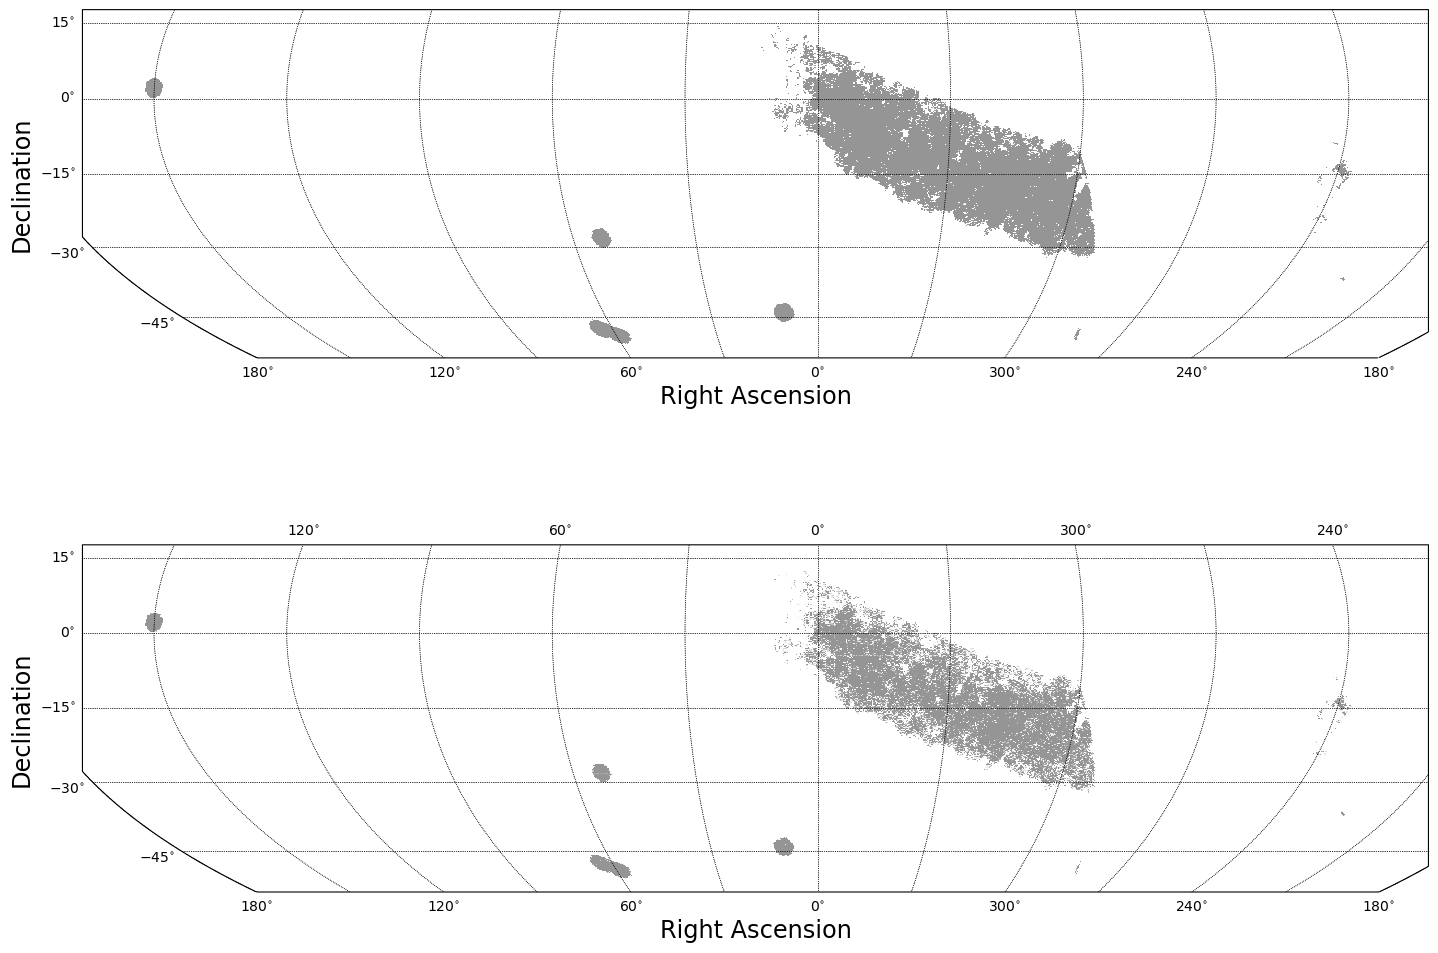

In [13]:
if os.path.exists(old_path):
    fig, axes = plt.subplots(2, 1, figsize=(14, 12))
    for ax, m, name in [(axes[0], old_geometry, 'object-based (old)'),
                        (axes[1], geometry, 'visit-based, 2x2 block (new)')]:
        sp = skyproj.McBrydeSkyproj(ax=ax, lon_0=0.0)
        sp.draw_hspmap(m, cmap='Greys', vmin=0, vmax=2)
        ax.set_title(f'{name}, {np.sum(m.get_values_pix(m.valid_pixels)) * pa:.1f} deg$^2$')
    plt.tight_layout()
    plt.show()

## Depth maps

10 sigma galaxy limiting magnitude per pixel, from Rubin's 5 sigma point-source maglim maps plus the
0.753 mag offset. Not dereddened.

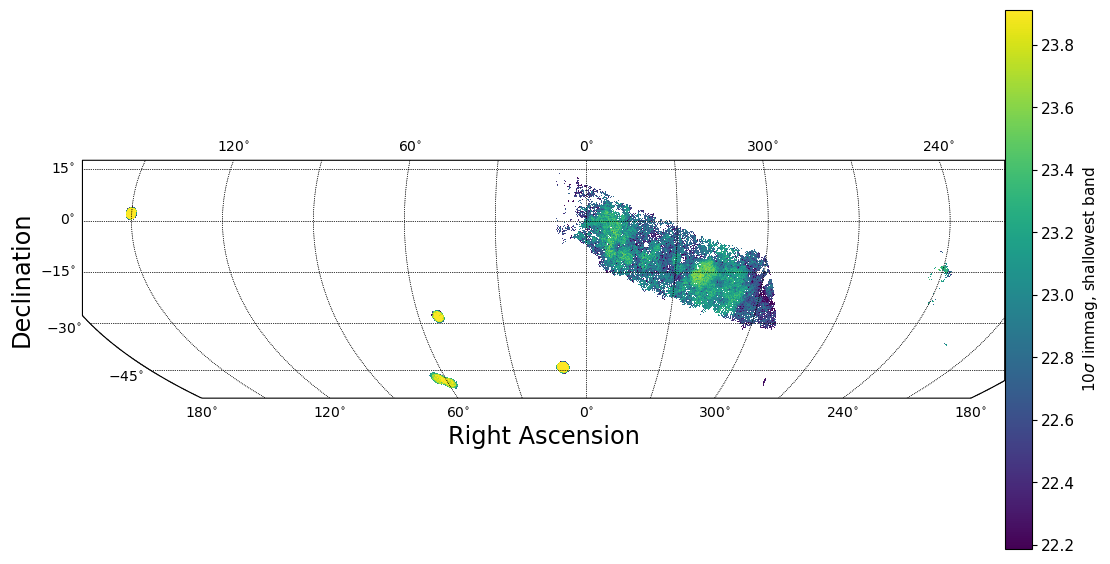

In [14]:
fig, ax = plt.subplots(figsize=(14, 7))
sp = skyproj.McBrydeSkyproj(ax=ax, lon_0=0.0)
lo, hi = np.percentile(limmag['min'], [2, 98])
sp.draw_hspmap(depth['min']['limmag'], cmap='viridis', vmin=lo, vmax=hi)
sp.draw_colorbar(label=r'10$\sigma$ limmag, shallowest band')
plt.show()

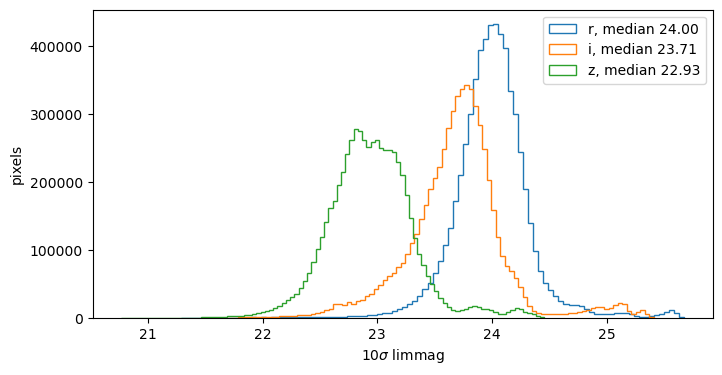

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
for d in ['r', 'i', 'z']:
    ax.hist(limmag[d], bins=100, histtype='step', label=f"{d}, median {np.median(limmag[d]):.2f}")
ax.set_xlabel(r'10$\sigma$ limmag')
ax.set_ylabel('pixels')
ax.legend()
plt.show()

z is the shallowest almost everywhere, which is why it's the reference band
and why `min` tracks it so closely.

## Spec-z

Unchanged from the last version except that the mask it sits inside is smaller now, so the
count is worth rechecking.

527159 spec-z in the file, 467149 still inside the new geometry


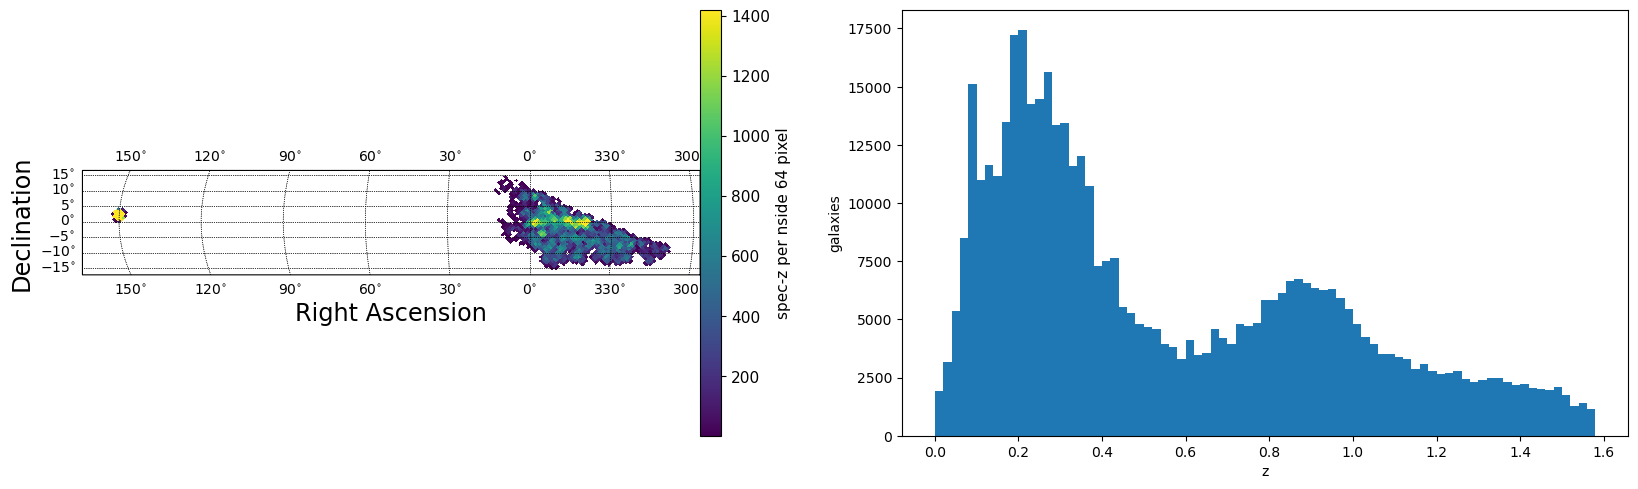

In [16]:
in_mask = geometry.get_values_pos(specz['ra'], specz['dec'], lonlat=True) > 0
print(f'{len(specz)} spec-z in the file, {in_mask.sum()} still inside the new geometry')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sp = skyproj.McBrydeSkyproj(ax=axes[0], lon_0=0.0)
sp.draw_hpxbin(specz['ra'][in_mask], specz['dec'][in_mask], nside=64)
sp.draw_colorbar(label='spec-z per nside 64 pixel')

axes[1].hist(specz['z'][in_mask], bins=np.arange(0, 1.6, 0.02))
axes[1].set_xlabel('z')
axes[1].set_ylabel('galaxies')
plt.tight_layout()
plt.show()

## Photometric catalog

cModel z for `refmag`, Sersic for the colors. GAaP is out.

1285272 galaxies sampled from all 886 tracts


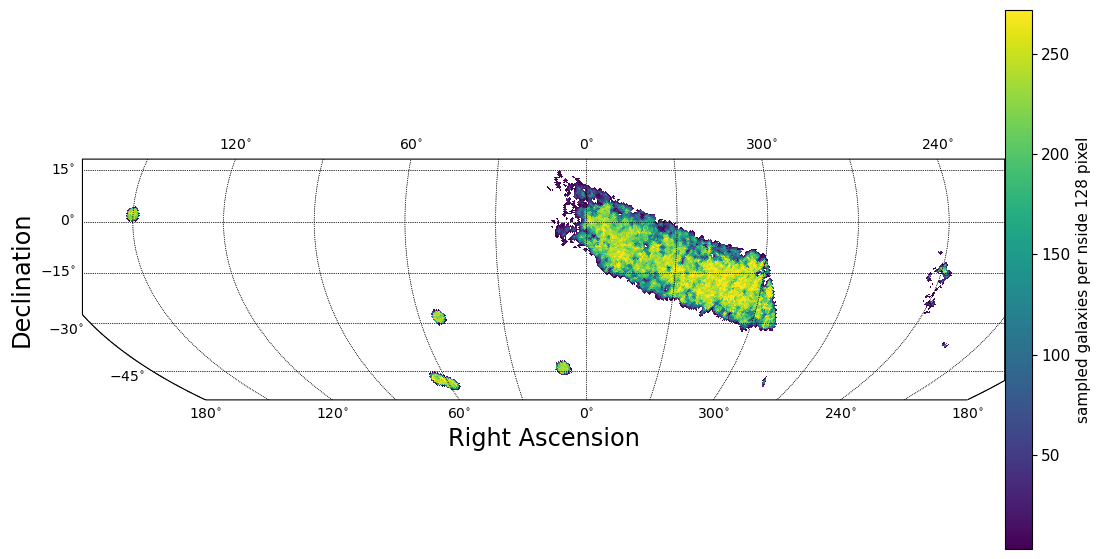

In [22]:
## looping through every tract for a galaxy density sample
## every tract, not every nth -- striding makes a checkerboard
ra_all, dec_all = [], []
for path in flux_files:
    g = fitsio.read(path, columns=['ra', 'dec'])[::80]
    ra_all.append(g['ra'])
    dec_all.append(g['dec'])
ra_all = np.concatenate(ra_all)
dec_all = np.concatenate(dec_all)
print(f'{len(ra_all)} galaxies sampled from all {len(flux_files)} tracts')

fig, ax = plt.subplots(figsize=(14, 7))
sp = skyproj.McBrydeSkyproj(ax=ax, lon_0=0.0)
sp.draw_hspmap(geometry, cmap='Greys', vmin=0, vmax=4)
sp.draw_hpxbin(ra_all, dec_all, nside=128)
sp.draw_colorbar(label='sampled galaxies per nside 128 pixel')
ax.set_title('catalog density on the geometry mask (grey)')
plt.show()

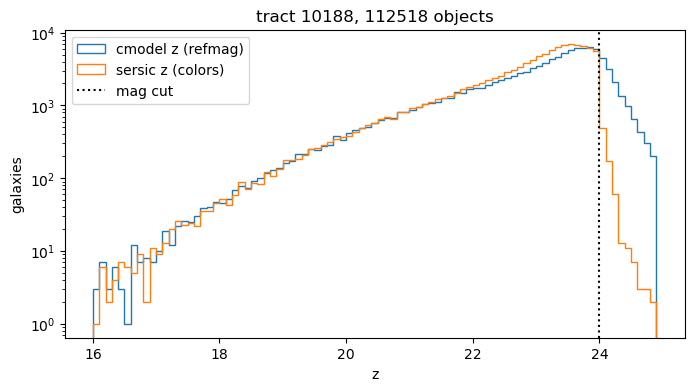

In [18]:
## magnitude distribution, one tract, both models
ref_i = bands.index('z')
path = common.flux_file(cat_dir, test_tracts[0], bands, vis_min)
if os.path.exists(path):
    g = fitsio.read(path)
    with np.errstate(invalid='ignore', divide='ignore'):
        refmag = common.flux_to_mag(g['cmodel_flux'][:, ref_i])
        colmag = common.flux_to_mag(g['sersic_flux'][:, ref_i])

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(refmag[np.isfinite(refmag)], bins=np.arange(16, 25, 0.1),
            histtype='step', label='cmodel z (refmag)')
    ax.hist(colmag[np.isfinite(colmag)], bins=np.arange(16, 25, 0.1),
            histtype='step', label='sersic z (colors)')
    ax.axvline(24.0, color='k', ls=':', label='mag cut')
    ax.set_xlabel('z')
    ax.set_ylabel('galaxies')
    ax.set_yscale('log')
    ax.legend()
    ax.set_title(f'tract {test_tracts[0]}, {len(g)} objects')
    plt.show()
else:
    print(f'{path} not there')

In [19]:
## the built catalog, once build has run
if have_catalog:
    master = fitsio.read(master_file, ext=1, lower=True)
    print(master.dtype.names)
    print(master)

    pixel_files = sorted(glob.glob(cat_base + '_0*.fit'))
    print(f'\n{len(pixel_files)} pixel files')
    g = fitsio.read(pixel_files[0], lower=True)
    print(g.dtype)
    print(f'{len(g)} galaxies in {os.path.basename(pixel_files[0])}')
else:
    print('build has not run yet')

('nside', 'hpix', 'ra_pix', 'dec_pix', 'ngals', 'filenames', 'lim_ref', 'ref_ind', 'area', 'nmag', 'mode', 'b', 'zeropoint', 'has_truth', 'has_zspec', 'r_ind', 'i_ind', 'z_ind')
[(32, [ 4547,  4673,  4674,  4675,  4676,  4800,  4801,  4802,  4803,  4928,  4929,  4930,  4931,  4932,  5055,  5056,  5057,  5058,  5059,  5060,  5182,  5183,  5184,  5185,  5186,  5187,  5188,  5309,  5310,  5311,  5312,  5313,  5314,  5436,  5437,  5438,  5439,  5440,  5441,  5442,  5564,  5565,  5566,  5567,  5568,  5569,  5570,  5621,  5690,  5691,  5692,  5693,  5694,  5695,  5696,  5697,  5698,  5699,  5749,  5750,  5817,  5818,  5819,  5820,  5821,  5822,  5823,  5824,  5825,  5826,  5876,  5877,  5878,  5944,  5945,  5946,  5947,  5948,  5949,  5950,  5951,  5952,  5953,  5954,  5956,  6005,  6006,  6071,  6072,  6073,  6074,  6075,  6076,  6077,  6078,  6079,  6080,  6081,  6082,  6083,  6133,  6197,  6198,  6199,  6200,  6201,  6202,  6203,  6204,  6205,  6206,  6207,  6208,  6209,  6210,  6211,  62

## redMaPPer format check

In [20]:
## geometry mask
print(mask_path := common.mask_file(map_dir, bands, vis_min, nside))
m = hsp.HealSparseMap.read(mask_path)
print(m)
print(m.get_values_pix(m.valid_pixels[:5]))

## depth map
print('\n' + (depth_path := common.depth_file(map_dir, bands, vis_min, nside)))
dm = hsp.HealSparseMap.read(depth_path)
print(dm)
print(dict(fitsio.read_header(depth_path, ext=0)))
print(dm.get_values_pix(dm.valid_pixels[:5]))

## config hpix
print('\nconfig hpix (RING, nside 2):', common.ring_hpix(geom_pix, nside, 2).tolist())

/home/dericj/dp2_redmapper/maps/dp2_geometry_riz_vis3_nside4096.hs
HealSparseMap: nside_coverage = 32, nside_sparse = 4096, float32, 6127224 valid pixels
[0.05371094 0.2939453  0.59375    0.02734375 0.05371094]

/home/dericj/dp2_redmapper/maps/dp2_depth_riz_vis3_nside4096.hs
HealSparseMap: nside_coverage = 32, nside_sparse = 4096, record array type.
[('exptime', '<f4'), ('limmag', '<f4'), ('m50', '<f4'), ('fracgood', '<f4')], 6127224 valid pixels
{'SIMPLE': True, 'BITPIX': 64, 'NAXIS': 1, 'NAXIS1': 12288, 'EXTEND': True, 'EXTNAME': 'COV', 'PIXTYPE': 'HEALSPARSE', 'NSIDE': 32, 'ZP': 22.5, 'NSIG': 10.0, 'NBAND': 1, 'W': 0.0, 'EFF': 1.0, 'COMMENT': 'dp2 depth, riz, 10.0 sigma galaxy'}
[(69.843796, 22.748257, 22.748257, 0.05371094)
 (74.06254 , 22.763847, 22.763847, 0.2939453 )
 (64.68751 , 22.76581 , 22.76581 , 0.59375   )
 (69.843765, 22.767015, 22.767015, 0.02734375)
 (61.407948, 22.622774, 22.622774, 0.05371094)]

config hpix (RING, nside 2): [12, 20, 23, 25, 26, 27, 28, 29, 33, 35, 36